In [32]:
import numpy as np
import matplotlib.pyplot as plt
from h5 import HDFArchive
from triqs.gf import *
from triqs.plot.mpl_interface import *

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
plt.rcParams['figure.dpi'] = 150
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['mathtext.rm'] = 'serif'
plt.rc('font', size=12)


In [33]:
data_loc = "/home/andrewhardy/Documents/Data/CTHYB_Data"
# f_cthyb = f"{data_loc}/cthyb_lambda--0.01-U-4.0_b-40.0_nw-500000_mins-10_lf=True.h5"
# f_ctseg = f"{data_loc}/ctseg_lambda--0.01-U-4.0_b-40.0.h5"
#f_cthyb = f"{data_loc}/cthyb_lambda--0.05-U-4.0_b-20.0_nw-100000_mins-22_lf=True.h5"
#f_cthyb = f"{data_loc}/cthyb_lambda--0.05-U-4.0_b-20.0_nw-100000_mins-22_lf=False.h5"
f_cthyb = f"{data_loc}/cthyb_lambda--0.1-U-4.0_b-20.0_nw-100000_mins-22_lf=True.h5"
f_cthyb = f"{data_loc}/cthyb_lambda-0.1-U-4.0_b-20.0_nw-100000_mins-40_lf=True.h5"

#f_cthyb = f"{data_loc}/cthyb_lambda--0.05-U-4.0_b-20.0_nw-500000_mins-10_lf=True.h5"

f_ctseg = f"{data_loc}/ctseg_lambda--0.1-U-4.0_b-20.0.h5"
with HDFArchive(f_cthyb, "r") as A:
    G_tau_hyb = A["G_tau"]
    G_tau_hyb["up"].data[:,0,0] = G_tau_hyb["up"].data[:,0,0]# +0.025
    Sz_hyb = A["O_tau"]
    K_n = A["K_n"]
    Q_tau = A["Q_tau"]
    average_sign = A["average_sign"]
with HDFArchive(f_ctseg, "r") as A:
    G_tau_seg = A["G_tau"]
    nn_seg = A["nn_tau"]


In [34]:
print(f"Average sign in CTHYB simulation: {average_sign:.4f}")

Average sign in CTHYB simulation: 1.0000


In [35]:
def analytic_K(tau, L, w0, beta):
    return -(L / w0**2) * (np.cosh(w0 * (tau - beta/2.0)) / np.sinh(w0 * beta / 2.0) - 1.0 / np.tanh(w0 * beta / 2.0))


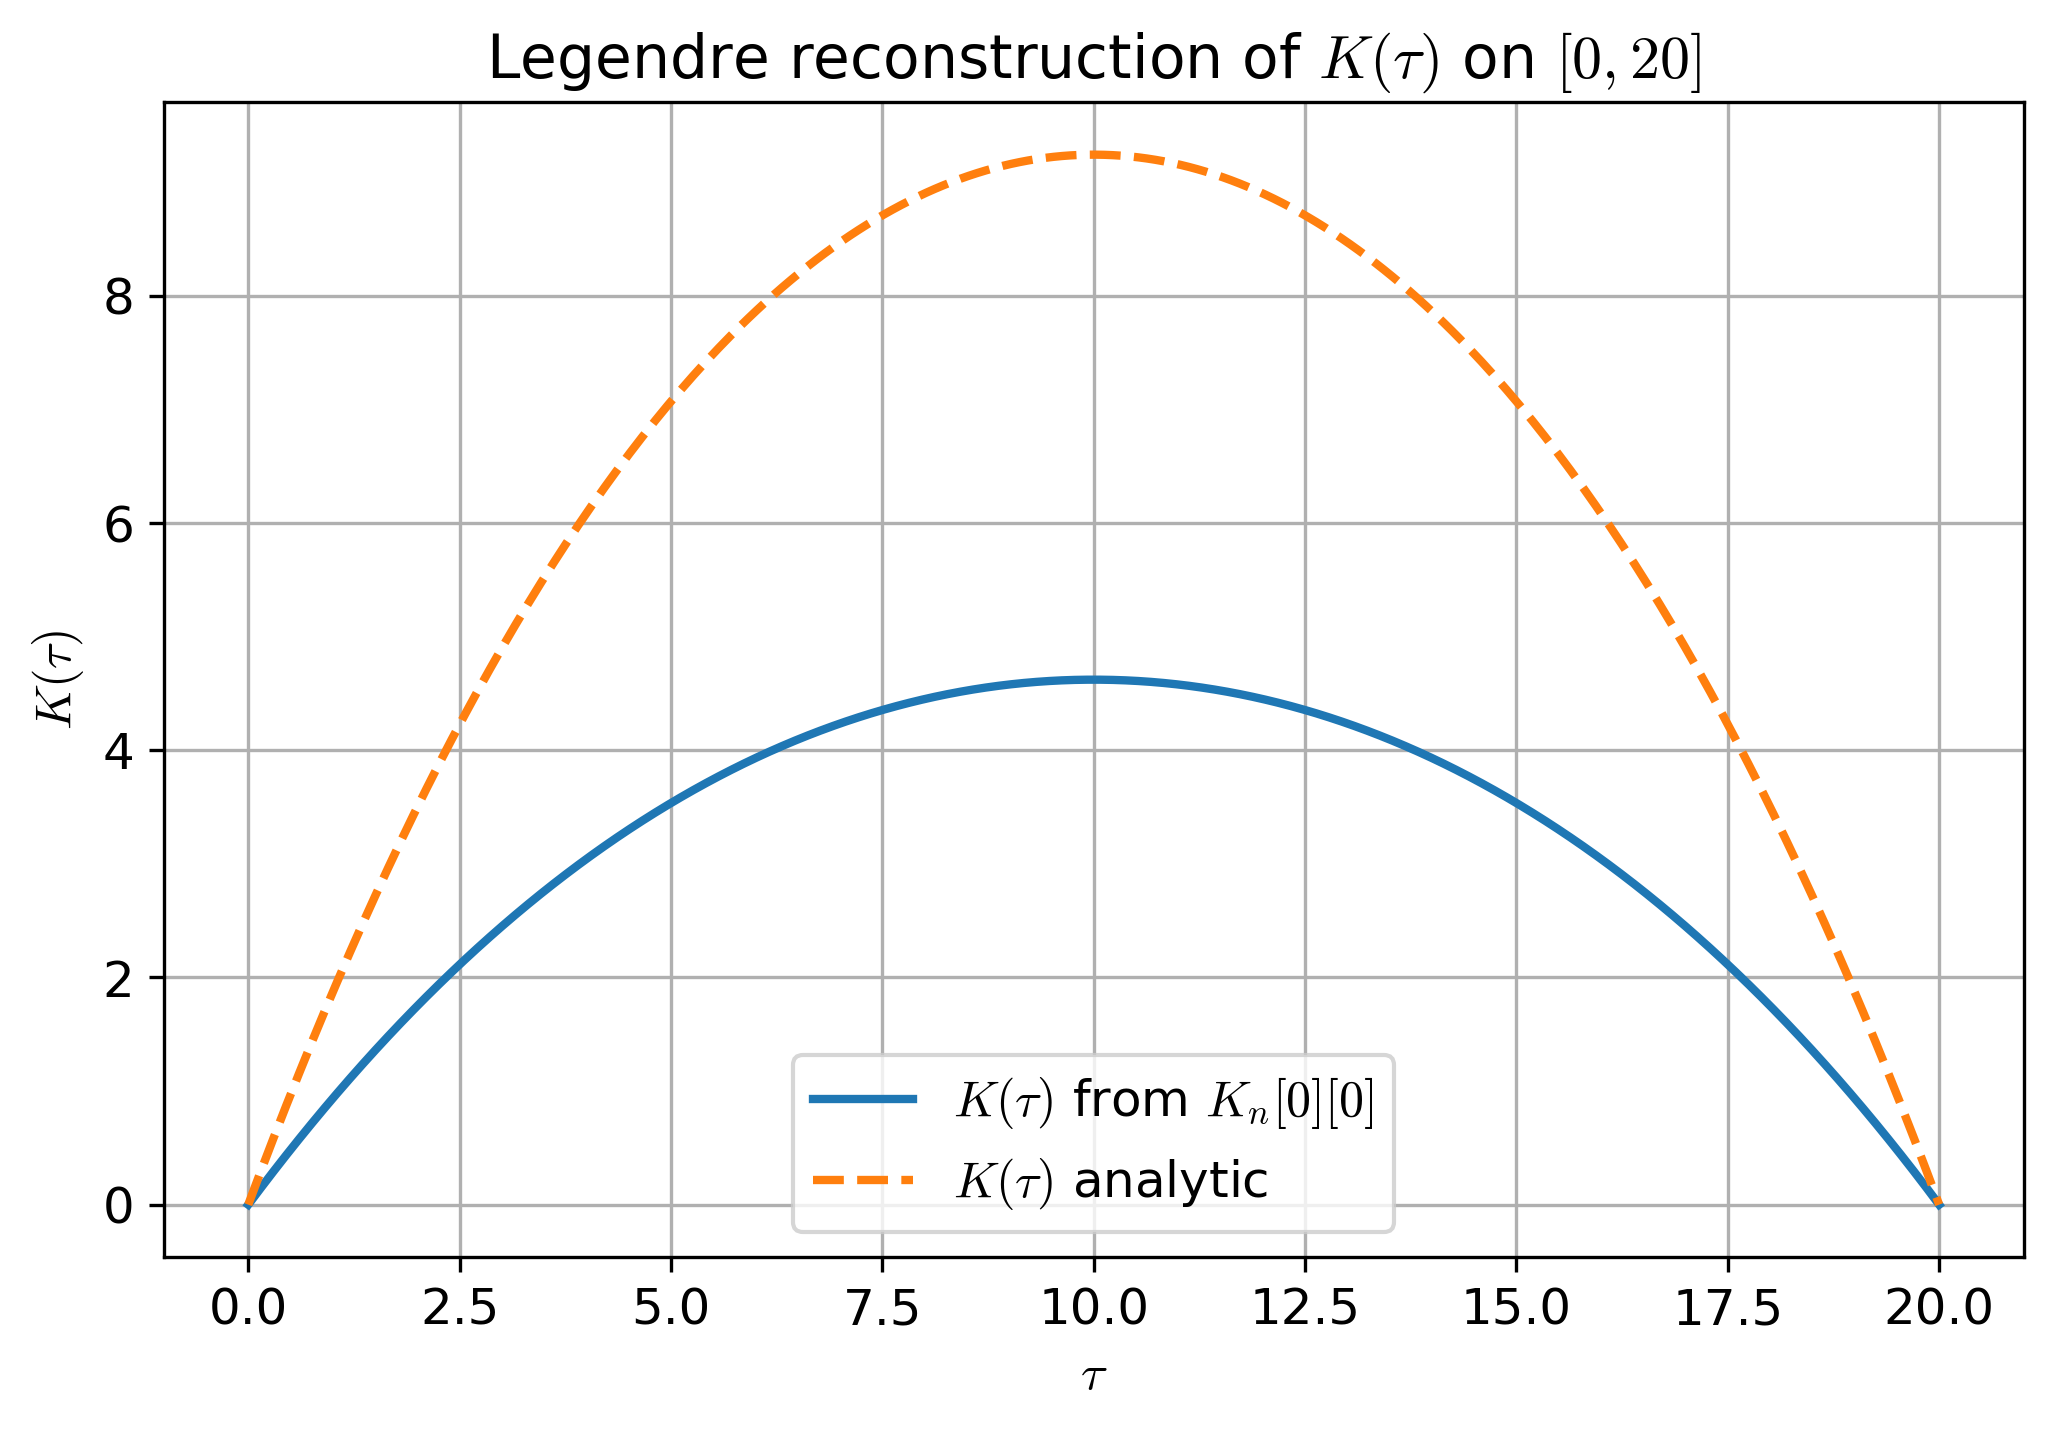

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import eval_legendre

# Coefficients of the Legendre expansion for the (up, up) block
coeffs = np.asarray(K_n[0][0]).real

# Evaluate the shifted Legendre series on tau in [0, 10]
beta_eval = 20.0
tau_mesh = np.linspace(0.0, beta_eval, 400)
x_mesh = 2.0 * tau_mesh / beta_eval - 1.0

K_tau = np.zeros_like(tau_mesh, dtype=float)
for n, c_n in enumerate(coeffs):
    K_tau += c_n * eval_legendre(n, x_mesh)
K_anal = analytic_K(tau_mesh, L=0.2, w0=0.1, beta=beta_eval)
plt.figure(figsize=(8, 5))
plt.plot(tau_mesh, K_tau, linewidth=2.0, label=r'$K(\tau)$ from $K_n[0][0]$')
plt.plot(tau_mesh, K_anal, linestyle = '--', linewidth=2.0, label=r'$K(\tau)$ analytic')
plt.xlabel(r'$\tau$')
plt.ylabel(r'$K(\tau)$')
plt.title(r'Legendre reconstruction of $K(\tau)$ on $[0, 20]$')
plt.grid(True)
plt.legend()
plt.show()

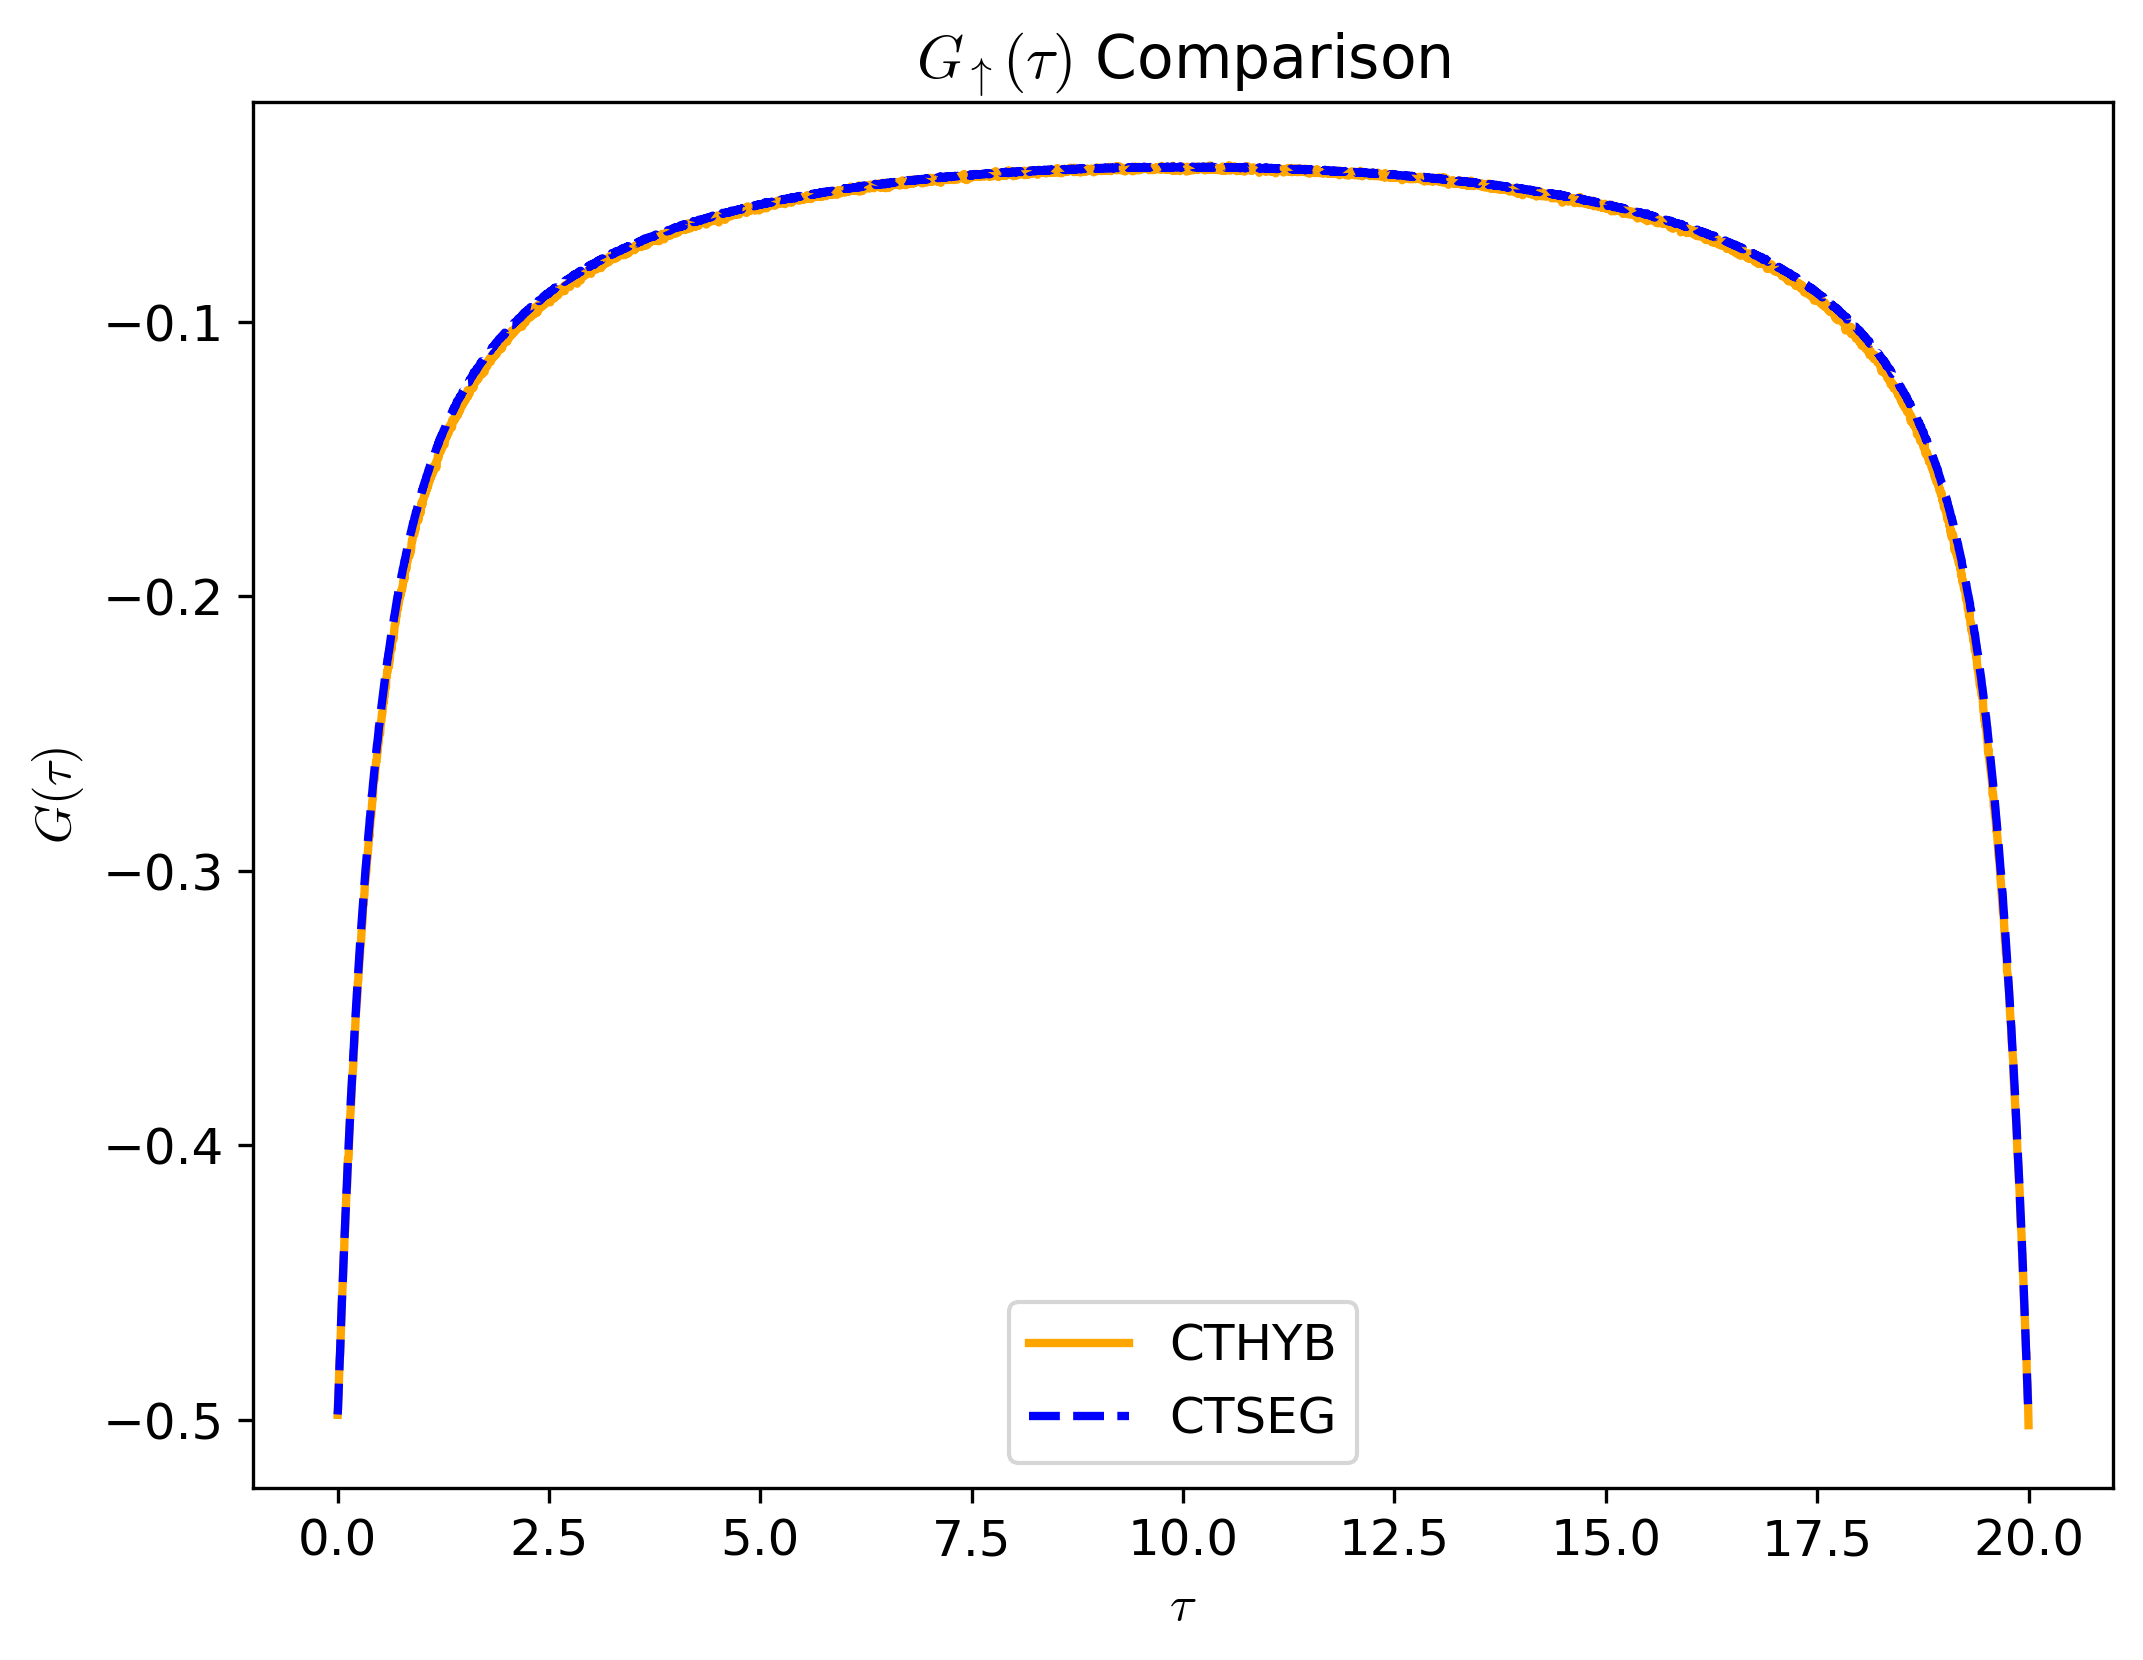

In [37]:
plt.figure(figsize=(8, 6))
oplot(G_tau_hyb["up"].real.real,"-", color="orange", linewidth=2.0, label="CTHYB")
oplot(G_tau_seg["up"].real, color="blue", linewidth=2.0, label="CTSEG", linestyle="--")
plt.title(r"$G_\uparrow(\tau)$ Comparison")
plt.ylabel(r"$G(\tau)$")
#plt.xlim(0,0.1)
#plt.ylim(-0.075,-0.00)
plt.legend()
plt.show()


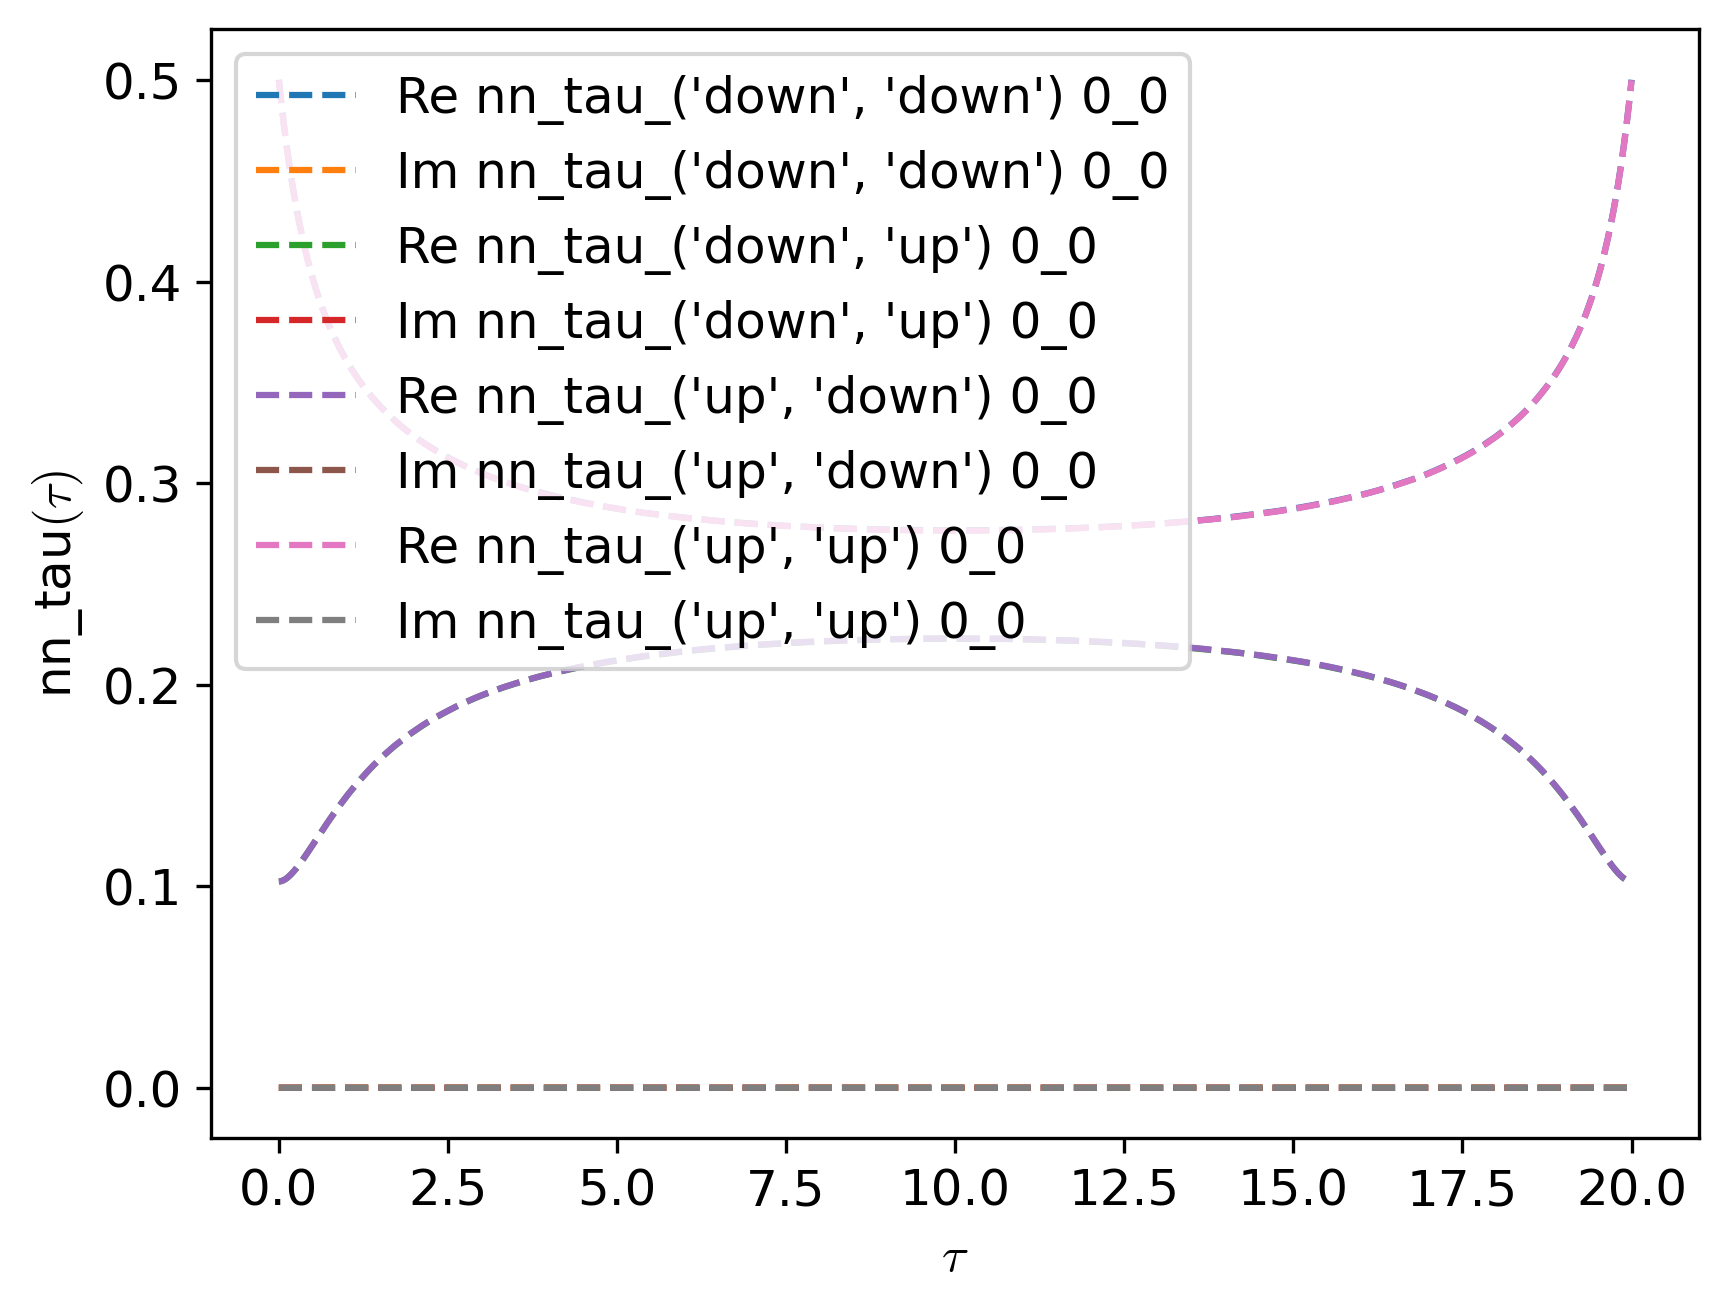

In [38]:
#oplot(Q_tau)
oplot(nn_seg, linestyle = "--")
legend = plt.legend()
#egend.set_visible(False)
plt.show()

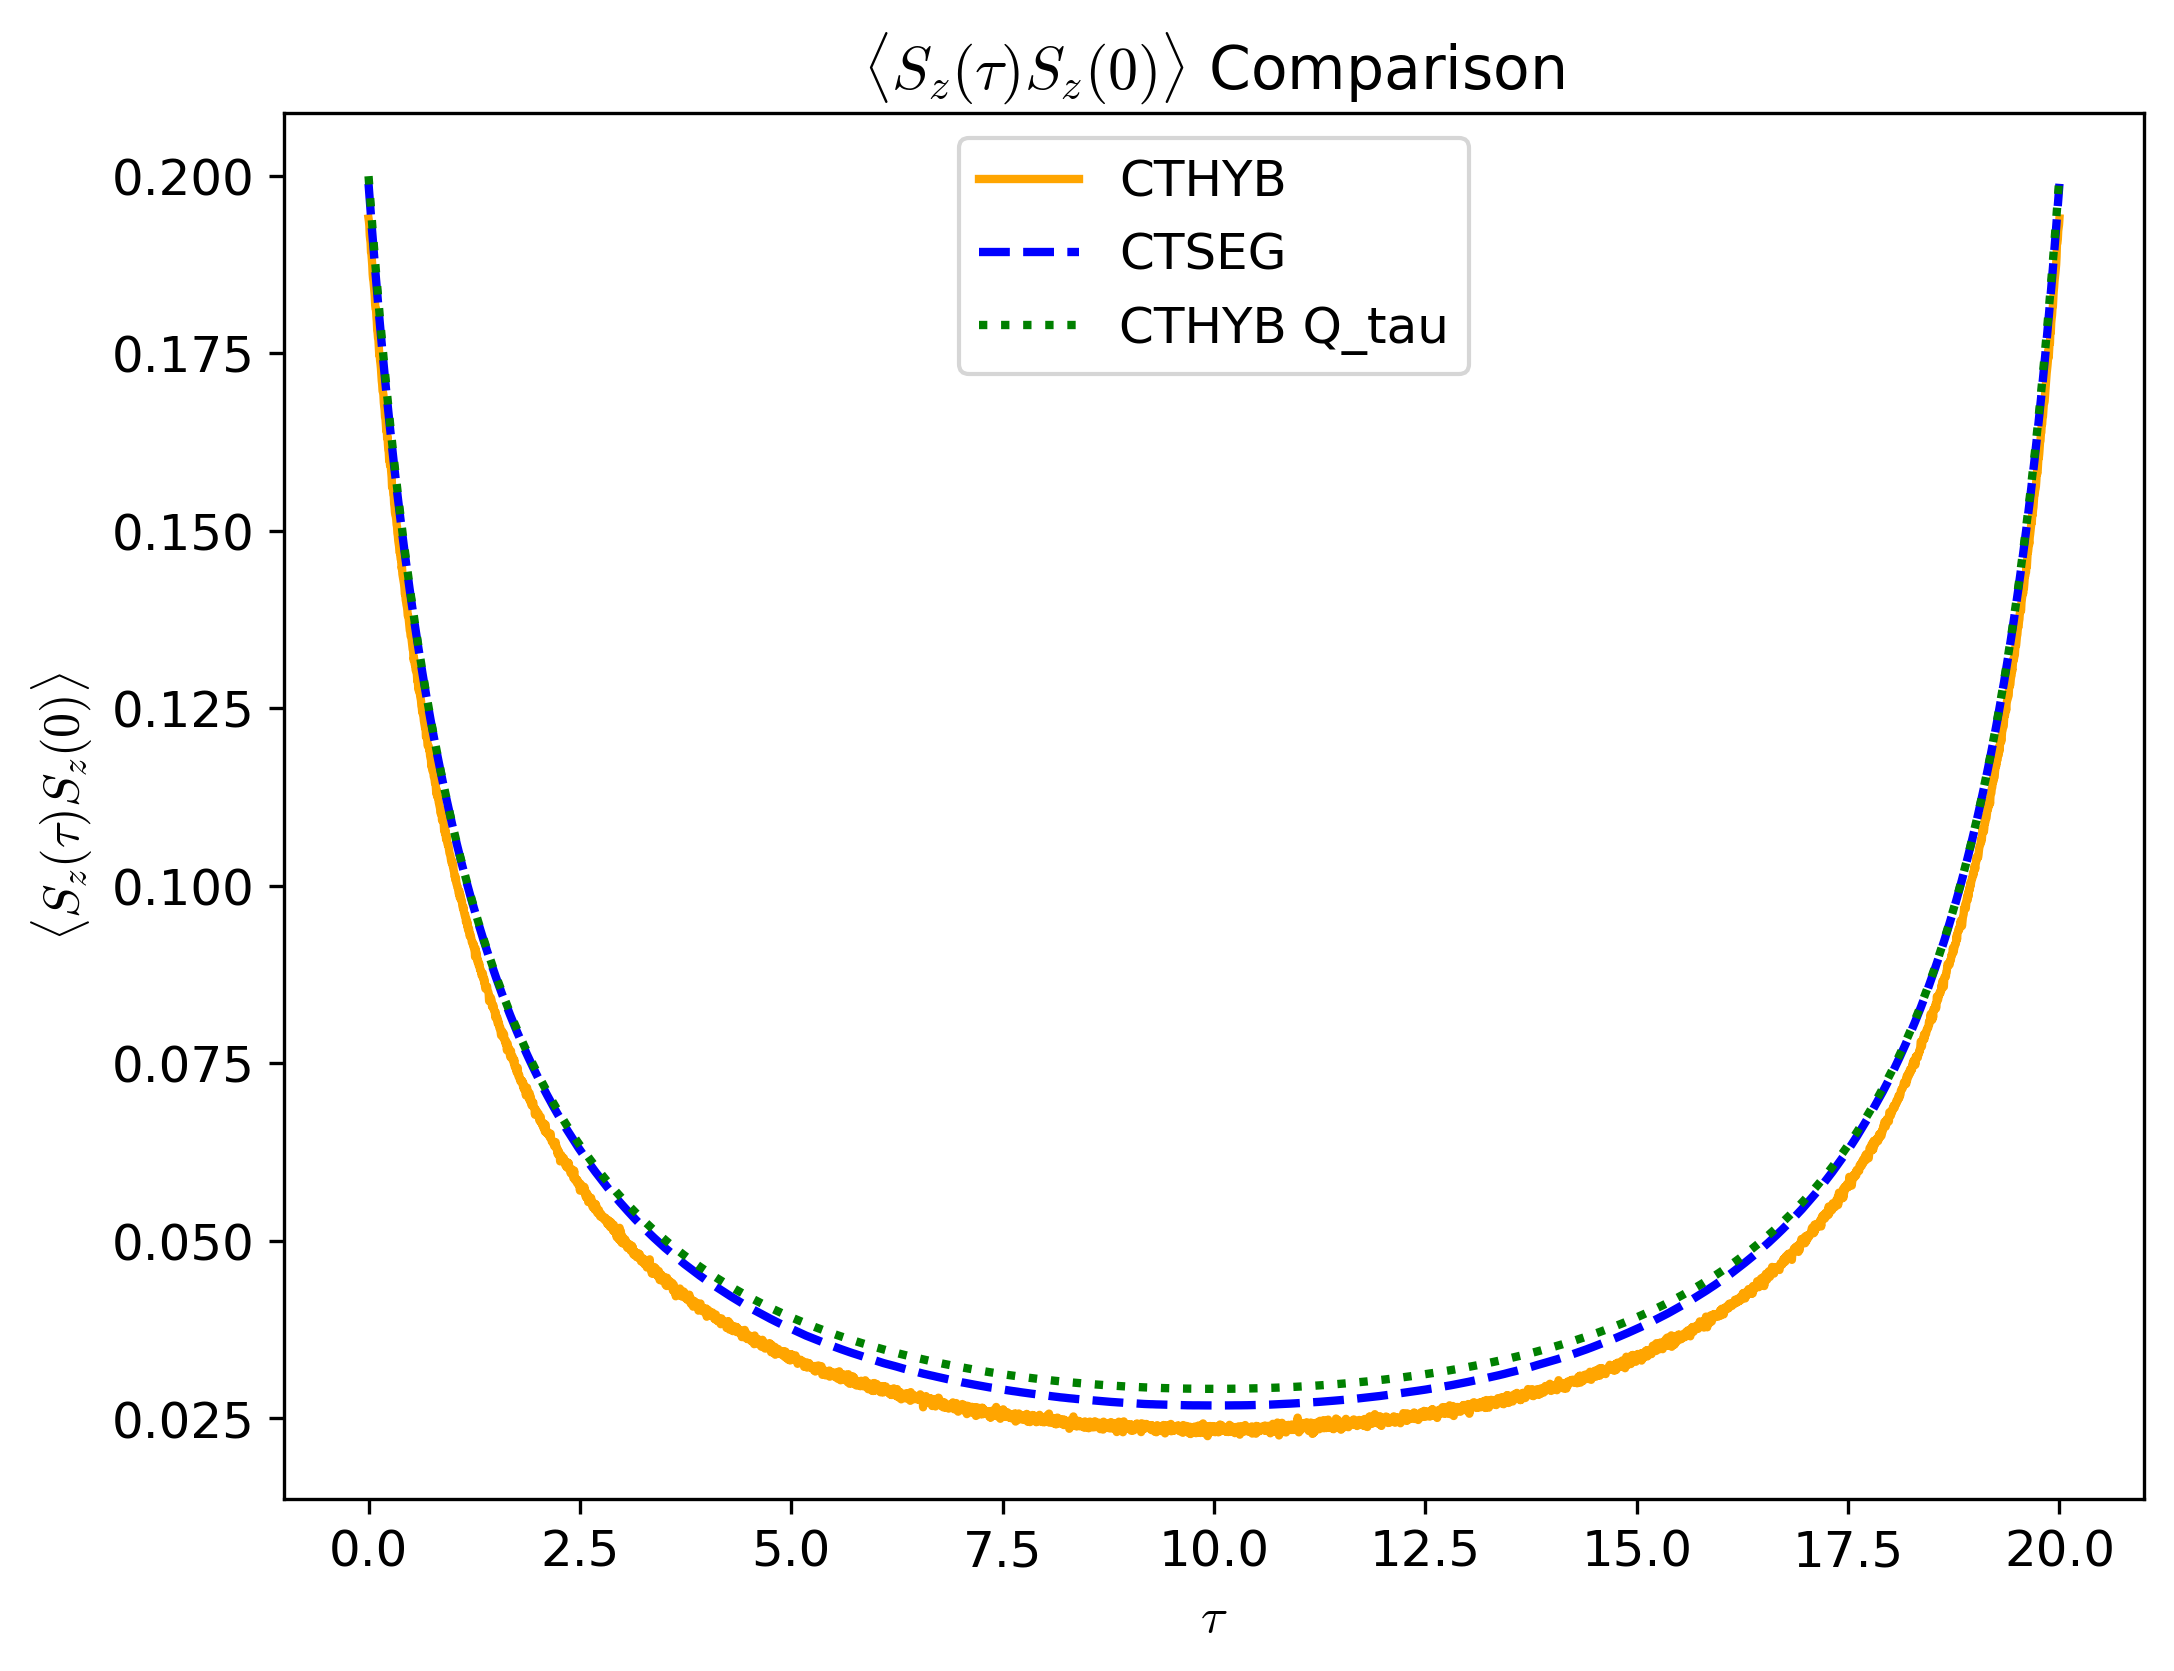

In [39]:
SzSz_seg = 0.25 * (nn_seg['up', 'up'].data[:, 0, 0].real
                 + nn_seg['down', 'down'].data[:, 0, 0].real
                 - nn_seg['up', 'down'].data[:, 0, 0].real
                 - nn_seg['down', 'up'].data[:, 0, 0].real)
SzSz_tau = 0.25*(Q_tau['up', 'up'].data[:, 0, 0].real + Q_tau['down', 'down'].data[:, 0, 0].real 
                 - Q_tau['up', 'down'].data[:, 0, 0].real - Q_tau['down', 'up'].data[:, 0, 0].real)  +0.2#
tau_seg = np.array([float(t) for t in nn_seg['up', 'up'].mesh]) 

tau_hyb = np.array([float(t) for t in Sz_hyb.mesh])
SzSz_hyb = Sz_hyb.data.real

plt.figure(figsize=(8, 6))
plt.plot(tau_hyb, SzSz_hyb, color="orange", linewidth=2.0, label="CTHYB")
plt.plot(tau_seg, SzSz_seg, color="blue", linewidth=2.0, label="CTSEG", linestyle="--")
plt.plot(tau_hyb, SzSz_tau, color="green", linewidth=2.0, label="CTHYB Q_tau", linestyle=":")
plt.title(r"$\langle S_z(\tau) S_z(0) \rangle$ Comparison")
plt.ylabel(r"$\langle S_z(\tau) S_z(0) \rangle$")
plt.xlabel(r"$\tau$")
plt.legend()
plt.show()
